Data Loading

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Loading all sheets
forest_filepath = r"C:\Users\ANAND\Desktop\Labmentix projects\bird species observation analysis\Bird_Monitoring_Data_FOREST.xlsx"
grass_filepath = r"C:\Users\ANAND\Desktop\Labmentix projects\bird species observation analysis\Bird_Monitoring_Data_GRASSLAND.xlsx"

In [3]:
# Reading the file with multiple sheets
excel_data1 = pd.ExcelFile(forest_filepath)
excel_data2 = pd.ExcelFile(grass_filepath)

In [4]:
# Getting all sheet names
sheet_names1 = excel_data1.sheet_names
sheet_names2 = excel_data2.sheet_names

In [5]:
# Reading data from all sheets into a dictionary
sheets_dict1 = {sheet: excel_data1.parse(sheet) for sheet in sheet_names1}
sheets_dict2 = {sheet: excel_data2.parse(sheet) for sheet in sheet_names2}

In [6]:
combined_df1 = pd.concat(
    [df.assign(Sheet=sheet_name) for sheet_name, df in sheets_dict1.items()],
    ignore_index=True
)
combined_df2 = pd.concat(
    [df.assign(Sheet=sheet_name) for sheet_name, df in sheets_dict2.items()],
    ignore_index=True
)

In [7]:
forest_df = combined_df1.drop(columns=['Sheet'])
grass_df = combined_df2.drop(columns=['Sheet'])

Preprocessing - data cleaning and feature engineering


In [8]:
forest_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8546 entries, 0 to 8545
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Admin_Unit_Code              8546 non-null   object        
 1   Sub_Unit_Code                722 non-null    object        
 2   Site_Name                    8546 non-null   object        
 3   Plot_Name                    8546 non-null   object        
 4   Location_Type                8546 non-null   object        
 5   Year                         8546 non-null   int64         
 6   Date                         8546 non-null   datetime64[ns]
 7   Start_Time                   8546 non-null   object        
 8   End_Time                     8546 non-null   object        
 9   Observer                     8546 non-null   object        
 10  Visit                        8546 non-null   int64         
 11  Interval_Length              8546 non-null 

In [9]:
forest_df.isnull().sum()

Admin_Unit_Code                   0
Sub_Unit_Code                  7824
Site_Name                         0
Plot_Name                         0
Location_Type                     0
Year                              0
Date                              0
Start_Time                        0
End_Time                          0
Observer                          0
Visit                             0
Interval_Length                   0
ID_Method                         1
Distance                         92
Flyover_Observed                  0
Sex                            5183
Common_Name                       0
Scientific_Name                   0
AcceptedTSN                       9
NPSTaxonCode                      0
AOU_Code                          0
PIF_Watchlist_Status              0
Regional_Stewardship_Status       0
Temperature                       0
Humidity                          0
Sky                               0
Wind                              0
Disturbance                 

In [10]:
forest_df.duplicated().sum()

np.int64(0)

Not removing null values as it would drastically reduce the data set to only 222 records

In [11]:
forest_df['Date'] = pd.to_datetime(forest_df['Date'])
forest_df['Year'] = forest_df['Date'].dt.year
forest_df['Month'] = forest_df['Date'].dt.month

In [12]:
# Observation duration
import pandas as pd
from datetime import datetime, time, timedelta

# Convert time objects to datetime by combining with a dummy date
def time_to_datetime(t):
    if isinstance(t, time):
        return datetime.combine(datetime.today().date(), t)
    return pd.to_datetime(t)

# Apply the conversion to both columns
forest_df['Start_Time'] = forest_df['Start_Time'].apply(time_to_datetime)
forest_df['End_Time'] = forest_df['End_Time'].apply(time_to_datetime)

# Calculate duration in minutes
forest_df['Observation_Duration'] = (forest_df['End_Time'] - forest_df['Start_Time']).dt.total_seconds()/60


In [13]:
# Season column
def get_season(month):
    if month in [12,1,2]:
        return 'Winter'
    elif month in [3,4,5]:
        return 'Summer'
    elif month in [6,7,8]:
        return 'Monsoon'
    else:
        return 'Post-Monsoon'
forest_df['Season'] = forest_df['Month'].apply(get_season)

In [14]:
forest_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8546 entries, 0 to 8545
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Admin_Unit_Code              8546 non-null   object        
 1   Sub_Unit_Code                722 non-null    object        
 2   Site_Name                    8546 non-null   object        
 3   Plot_Name                    8546 non-null   object        
 4   Location_Type                8546 non-null   object        
 5   Year                         8546 non-null   int32         
 6   Date                         8546 non-null   datetime64[ns]
 7   Start_Time                   8546 non-null   datetime64[ns]
 8   End_Time                     8546 non-null   datetime64[ns]
 9   Observer                     8546 non-null   object        
 10  Visit                        8546 non-null   int64         
 11  Interval_Length              8546 non-null 

In [15]:
grass_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8531 entries, 0 to 8530
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Admin_Unit_Code              8531 non-null   object        
 1   Sub_Unit_Code                0 non-null      object        
 2   Plot_Name                    8531 non-null   object        
 3   Location_Type                8531 non-null   object        
 4   Year                         8531 non-null   object        
 5   Date                         8531 non-null   datetime64[ns]
 6   Start_Time                   8531 non-null   object        
 7   End_Time                     8531 non-null   object        
 8   Observer                     8531 non-null   object        
 9   Visit                        8531 non-null   object        
 10  Interval_Length              8531 non-null   object        
 11  ID_Method                    8530 non-null 

In [16]:
grass_df.isnull().sum()

Admin_Unit_Code                   0
Sub_Unit_Code                  8531
Plot_Name                         0
Location_Type                     0
Year                              0
Date                              0
Start_Time                        0
End_Time                          0
Observer                          0
Visit                             0
Interval_Length                   0
ID_Method                         1
Distance                       1394
Flyover_Observed                  0
Sex                               0
Common_Name                       0
Scientific_Name                   0
AcceptedTSN                      24
TaxonCode                         2
AOU_Code                          0
PIF_Watchlist_Status              0
Regional_Stewardship_Status       0
Temperature                       0
Humidity                          0
Sky                               0
Wind                              0
Disturbance                       0
Previously_Obs              

Not removing null values as it would drastically reduce the data set 

In [17]:
grass_df.duplicated().sum()

np.int64(1705)

In [18]:
grass_df.drop_duplicates(inplace=True)

In [19]:
grass_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6826 entries, 0 to 8521
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Admin_Unit_Code              6826 non-null   object        
 1   Sub_Unit_Code                0 non-null      object        
 2   Plot_Name                    6826 non-null   object        
 3   Location_Type                6826 non-null   object        
 4   Year                         6826 non-null   object        
 5   Date                         6826 non-null   datetime64[ns]
 6   Start_Time                   6826 non-null   object        
 7   End_Time                     6826 non-null   object        
 8   Observer                     6826 non-null   object        
 9   Visit                        6826 non-null   object        
 10  Interval_Length              6826 non-null   object        
 11  ID_Method                    6825 non-null   obj

In [20]:
grass_df['Date'] = pd.to_datetime(grass_df['Date'])
grass_df['Year'] = grass_df['Date'].dt.year
grass_df['Month'] = grass_df['Date'].dt.month

In [21]:
# Observation duration
import pandas as pd
from datetime import datetime, time, timedelta

# Convert time objects to datetime by combining with a dummy date
def time_to_datetime(t):
    if isinstance(t, time):
        return datetime.combine(datetime.today().date(), t)
    return pd.to_datetime(t)

# Apply the conversion to both columns
grass_df['Start_Time'] = grass_df['Start_Time'].apply(time_to_datetime)
grass_df['End_Time'] = grass_df['End_Time'].apply(time_to_datetime)

# Calculate duration in minutes
grass_df['Observation_Duration'] = (grass_df['End_Time'] - grass_df['Start_Time']).dt.total_seconds()/60

In [22]:
# Season column
def get_season(month):
    if month in [12,1,2]:
        return 'Winter'
    elif month in [3,4,5]:
        return 'Summer'
    elif month in [6,7,8]:
        return 'Monsoon'
    else:
        return 'Post-Monsoon'
grass_df['Season'] = grass_df['Month'].apply(get_season)

In [23]:
grass_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6826 entries, 0 to 8521
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Admin_Unit_Code              6826 non-null   object        
 1   Sub_Unit_Code                0 non-null      object        
 2   Plot_Name                    6826 non-null   object        
 3   Location_Type                6826 non-null   object        
 4   Year                         6826 non-null   int32         
 5   Date                         6826 non-null   datetime64[ns]
 6   Start_Time                   6826 non-null   datetime64[ns]
 7   End_Time                     6826 non-null   datetime64[ns]
 8   Observer                     6826 non-null   object        
 9   Visit                        6826 non-null   object        
 10  Interval_Length              6826 non-null   object        
 11  ID_Method                    6825 non-null   obj

In [24]:
bird_df = pd.concat([forest_df, grass_df], ignore_index=True)

In [25]:
bird_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15372 entries, 0 to 15371
Data columns (total 34 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Admin_Unit_Code              15372 non-null  object        
 1   Sub_Unit_Code                722 non-null    object        
 2   Site_Name                    8546 non-null   object        
 3   Plot_Name                    15372 non-null  object        
 4   Location_Type                15372 non-null  object        
 5   Year                         15372 non-null  int32         
 6   Date                         15372 non-null  datetime64[ns]
 7   Start_Time                   15372 non-null  datetime64[ns]
 8   End_Time                     15372 non-null  datetime64[ns]
 9   Observer                     15372 non-null  object        
 10  Visit                        15372 non-null  object        
 11  Interval_Length              15372 non-nu

In [26]:
#bird_df.to_csv('bird.csv')

Exploratory data analysis

Temporal analysis

In [27]:
# Observations per day
yearly_obs = bird_df.groupby('Date')['Scientific_Name'].count()

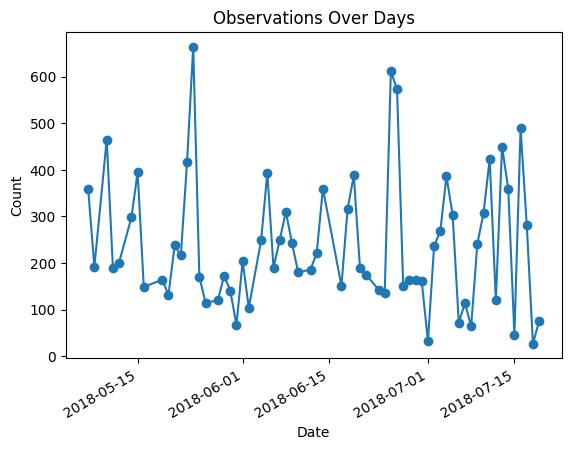

In [28]:
plt.figure()
yearly_obs.plot(kind='line', marker='o')
plt.title("Observations Over Days")
plt.ylabel("Count")
plt.show()

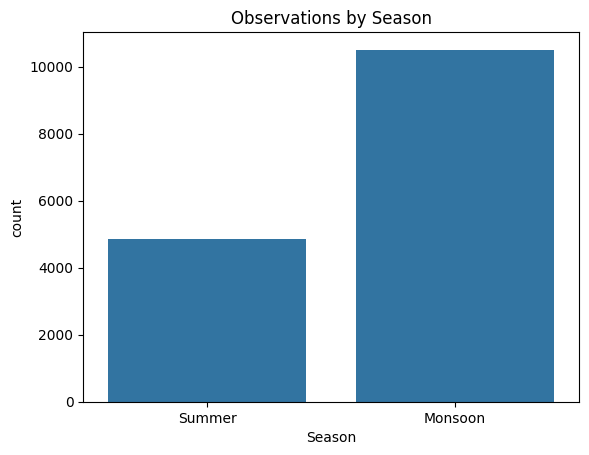

In [29]:
# Season distribution
plt.figure()
sns.countplot(x='Season', data=bird_df)
plt.title("Observations by Season")
plt.show()

In [41]:
#Hourly observation
timewise_obs = bird_df.groupby('Start_Time')['Scientific_Name'].count()

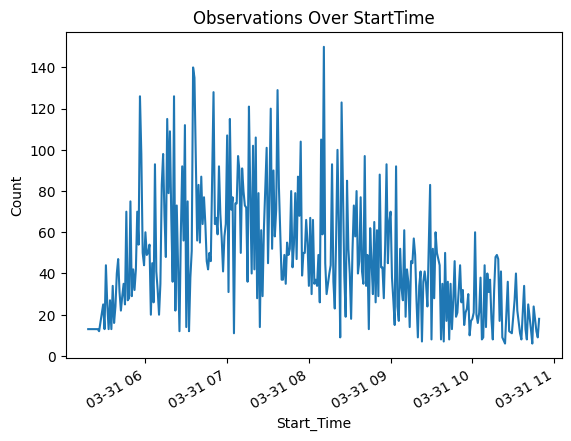

In [43]:
plt.figure()
timewise_obs.plot(kind='line')
plt.title("Observations Over StartTime")
plt.ylabel("Count")
plt.show()

Spatial (Habitat) Analysis

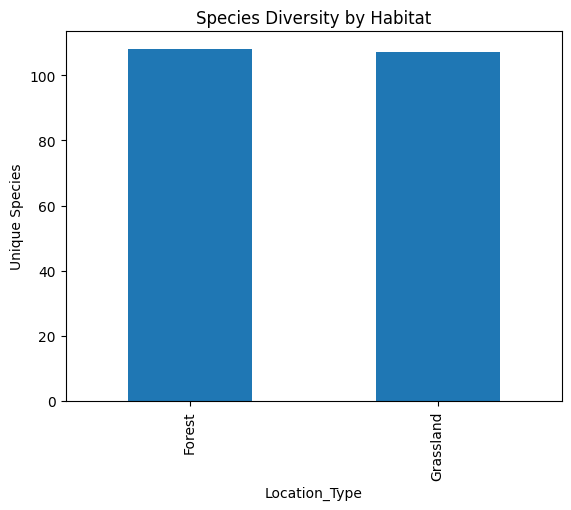

In [30]:
# Species count by habitat
species_habitat = bird_df.groupby('Location_Type')['Scientific_Name'].nunique()

plt.figure()
species_habitat.plot(kind='bar')
plt.title("Species Diversity by Habitat")
plt.ylabel("Unique Species")
plt.show()

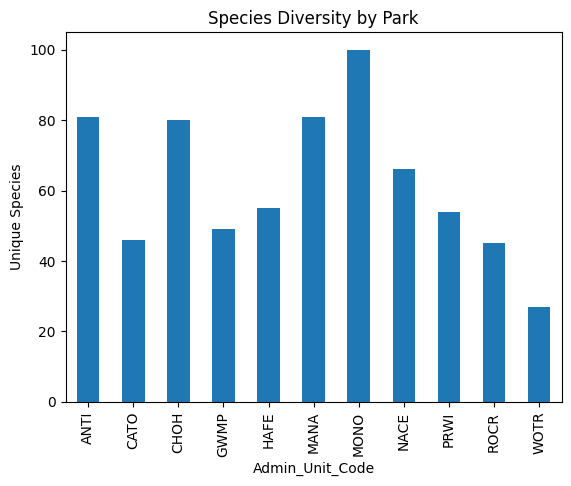

In [48]:
#Plot level analysis
species_plot = bird_df.groupby('Admin_Unit_Code')['Scientific_Name'].nunique()

plt.figure()
species_plot.plot(kind='bar')
plt.title("Species Diversity by Park")
plt.ylabel("Unique Species")
plt.show()

Species Analysis

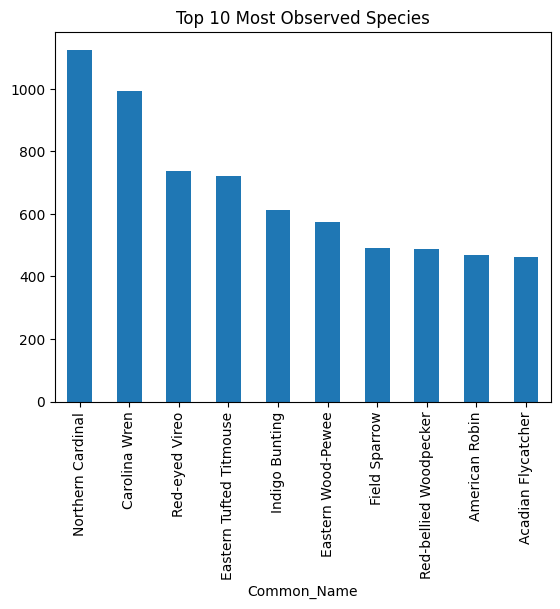

In [31]:
top_species = bird_df['Common_Name'].value_counts().head(10)

plt.figure()
top_species.plot(kind='bar')
plt.title("Top 10 Most Observed Species")
plt.show()

Activity Patterns

In [52]:
activity = bird_df.groupby('ID_Method')['Interval_Length'].count()

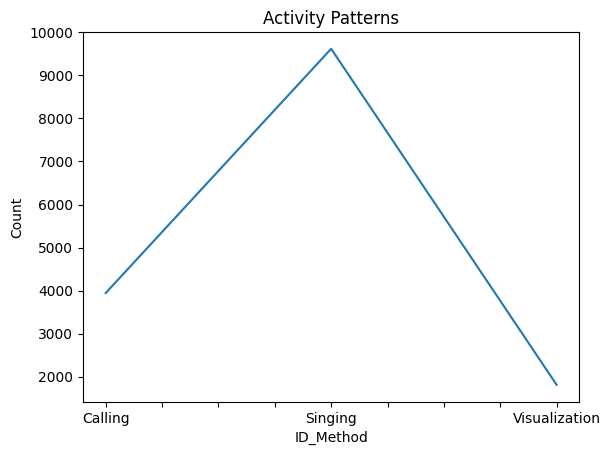

In [53]:
plt.figure()
activity.plot(kind='line')
plt.title("Activity Patterns")
plt.ylabel("Count")
plt.show()

Environmental Analysis

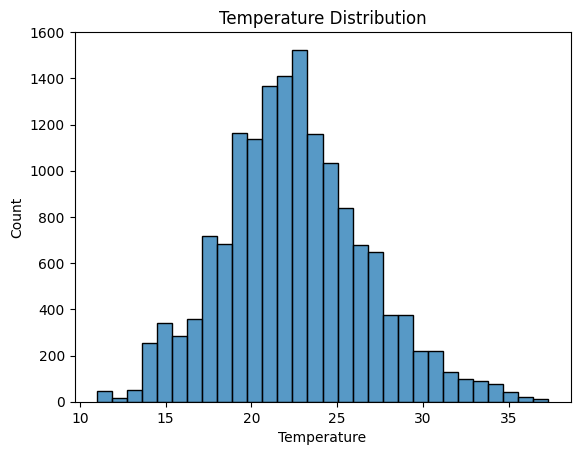

In [32]:
# Temperature vs observations
plt.figure()
sns.histplot(bird_df['Temperature'], bins=30)
plt.title("Temperature Distribution")
plt.show()

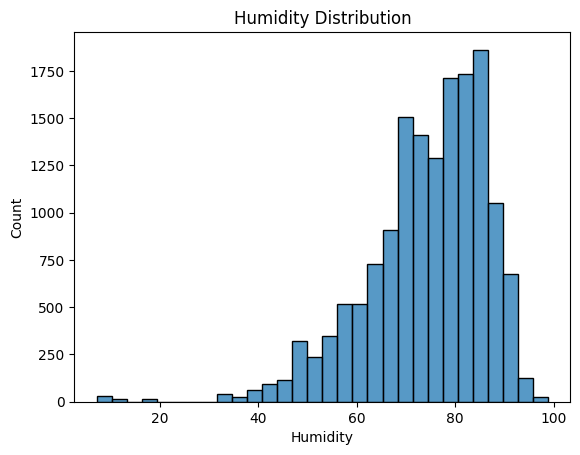

In [54]:
#Humidity vs observations
plt.figure()
sns.histplot(bird_df['Humidity'], bins=30)
plt.title("Humidity Distribution")
plt.show()

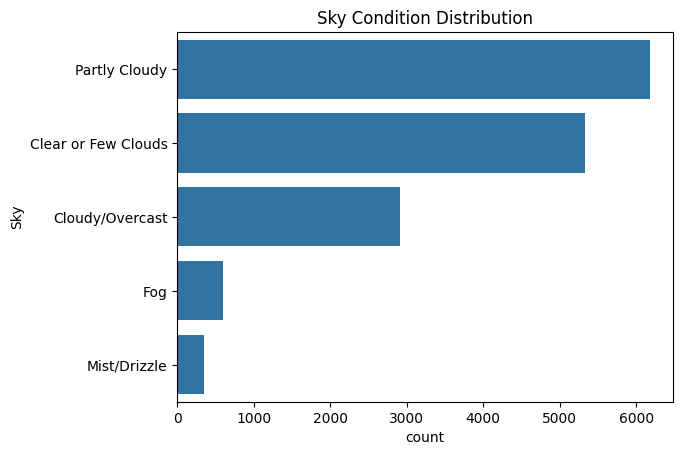

In [33]:
# Sky condition
plt.figure()
sns.countplot(y='Sky', data=bird_df, order=bird_df['Sky'].value_counts().index)
plt.title("Sky Condition Distribution")
plt.show()

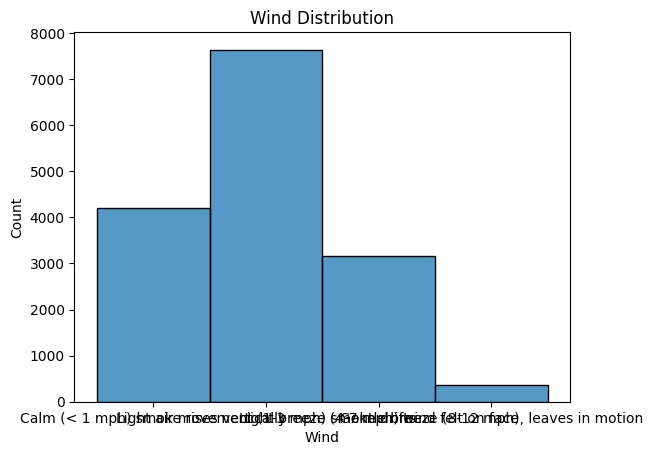

In [58]:
# Wind vs observations
plt.figure()
sns.histplot(bird_df['Wind'], bins=30)
plt.title("Wind Distribution")
plt.show()

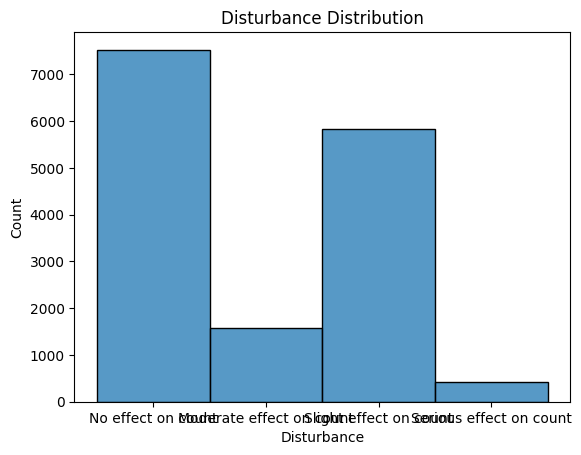

In [59]:
# Disturbance effect
# Disturbance vs observations
plt.figure()
sns.histplot(bird_df['Disturbance'], bins=30)
plt.title("Disturbance Distribution")
plt.show()

Distance & Behavior

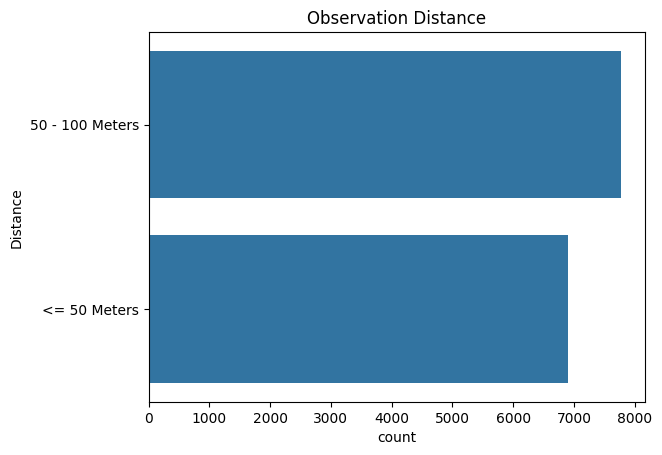

In [34]:
# Distance analysis
plt.figure()
sns.countplot(y='Distance', data=bird_df, order=bird_df['Distance'].value_counts().index)
plt.title("Observation Distance")
plt.show()

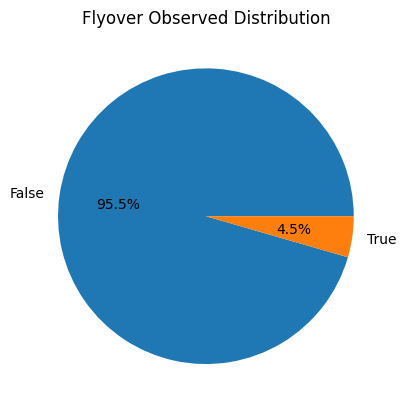

In [35]:
# Flyover behavior
plt.figure()
bird_df['Flyover_Observed'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Flyover Observed Distribution")
plt.ylabel("")
plt.show()

Observer Trends

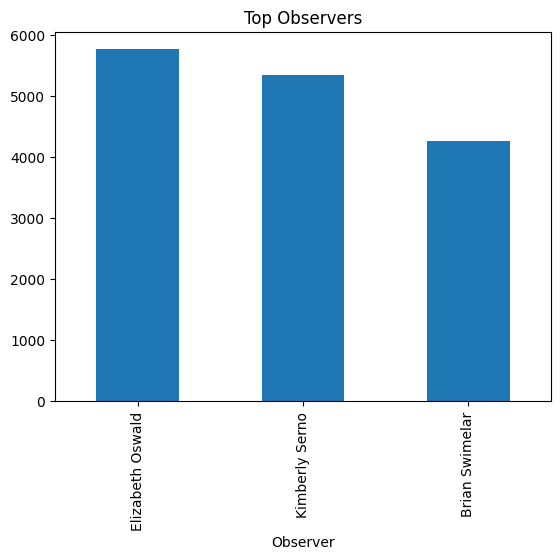

In [60]:
#Observer bias
top_observers = bird_df['Observer'].value_counts().head(10)

plt.figure()
top_observers.plot(kind='bar')
plt.title("Top Observers")
plt.show()

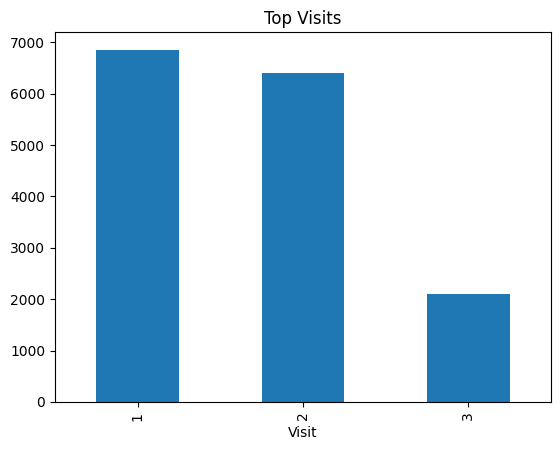

In [61]:
#Visit patterns
visitors = bird_df['Visit'].value_counts().head(10)

plt.figure()
visitors.plot(kind='bar')
plt.title("Top Visits")
plt.show()

Conservation Insights

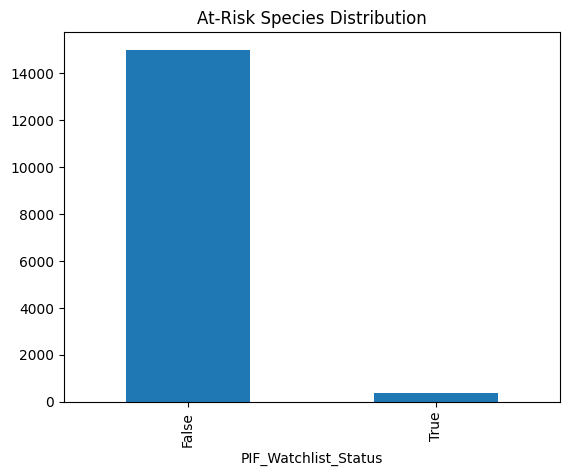

In [37]:
# Watchlist species
plt.figure()
bird_df['PIF_Watchlist_Status'].value_counts().plot(kind='bar')
plt.title("At-Risk Species Distribution")
plt.show()

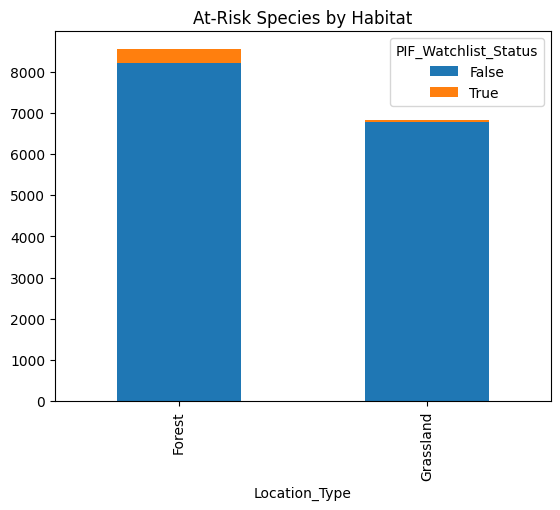

In [38]:
# Habitat vs at-risk
risk_by_habitat = bird_df.groupby('Location_Type')['PIF_Watchlist_Status'].value_counts().unstack()

risk_by_habitat.plot(kind='bar', stacked=True)
plt.title("At-Risk Species by Habitat")
plt.show()

Corelation

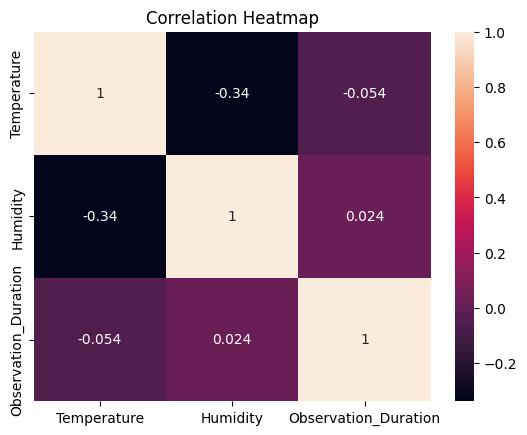

In [39]:
corr = bird_df[['Temperature', 'Humidity', 'Observation_Duration']].corr()

plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [40]:
print("Total Observations:", len(bird_df))
print("Unique Species:", bird_df['Scientific_Name'].nunique())
print("Most Common Species:", bird_df['Common_Name'].value_counts().idxmax())

Total Observations: 15372
Unique Species: 127
Most Common Species: Northern Cardinal


In [67]:
print("vulnerable Species:", bird_df['PIF_Watchlist_Status'].value_counts())

vulnerable Species: PIF_Watchlist_Status
False    14994
True       378
Name: count, dtype: int64


In [68]:
print("At risk Species:", bird_df['Regional_Stewardship_Status'].value_counts())

At risk Species: Regional_Stewardship_Status
False    11482
True      3890
Name: count, dtype: int64
